In [8]:
import os
import sys
import pandas as pd
from pathlib import Path
from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from utils.dataset.config import DatasetPath
from utils.dataset.clickstream_generator import generate_clickstream

# Dataset Path
- `recsys/data/dataset/` 하위 경로 생성

In [9]:
# 현재 Jupyter Notebook 실행 경로 (e.g., `documents/recsys/2_dataset`)
current_dir = os.path.abspath(os.curdir)

# `../recsys` 경로
base_dir = "/".join(current_dir.split("/")[:-1])

# 데이터셋 경로
dataset_dir = Path(base_dir).joinpath("data/dataset")

paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

# Clickstream Dataset
- 가상의 클릭 스트림 데이터 생성

In [10]:
generate_clickstream(
    user_metadata_path=paths.user_metadata_path,  # 유저 메타데이터 parquet 파일
    item_metadata_path=paths.item_metadata_path,  # 아이템 메타데이터 parquet 파일
    save_path=paths.interactions_path,  # 생성된 클릭스트림 parquet 파일 저장 경로
    users_per_chunk=1000,  # 유저별 로그를 나누어 저장할 단위 (1,000명씩 저장)
    n_sessions_per_user=5,  # 각 유저가 가질 세션 개수
    actions=["click", "wishlist", "cart", "purchase"],  # 행동 유형
    action_weights=[0.8, 0.1, 0.05, 0.05],  # 행동별 확률
    similarity_keys=[
        "category",
        "style",
        "color",
    ],  # 유사 아이템을 묶을 기준
    start_date=datetime(2025, 9, 1),  # 클릭 로그 시작 시점
    seed=42,  # 랜덤 시드 (재현성)
)

# Load Dataset

In [11]:
df = pd.read_parquet(paths.interactions_path)

In [12]:
df.shape

(162267, 14)

In [13]:
df.head()

,user_id,item_id,timestamp,action,age,gender,title,color,style,fit,material,season,sleeve,category
0,1,1818,2025-09-21 03:01:00,click,46,F,간절기 한정 린넨 소재 오렌지 점퍼,오렌지,빈티지,오버핏,린넨,간절기,숏,점퍼
1,1,8991,2025-09-21 03:02:00,click,46,F,필수템! 빈티지 무드의 간절기용 점퍼,오렌지,빈티지,루즈핏,데님,간절기,롱,점퍼
2,1,8798,2025-09-21 03:05:00,click,46,F,세미오버핏 실루엣의 아크릴 점퍼,오렌지,빈티지,세미오버핏,아크릴,간절기,숏,점퍼
3,1,5014,2025-09-21 03:04:00,click,46,F,"겨울 시즌, 빈티지 무드의 오렌지 폴리 7부 레귤러핏 점퍼",오렌지,빈티지,레귤러핏,폴리,겨울,7부,점퍼
4,1,15,2025-09-21 03:17:00,click,46,F,빈티지 무드의 오렌지 점퍼,오렌지,빈티지,슬림핏,플리스,봄,숏,점퍼


# EDA

## Item Frequency

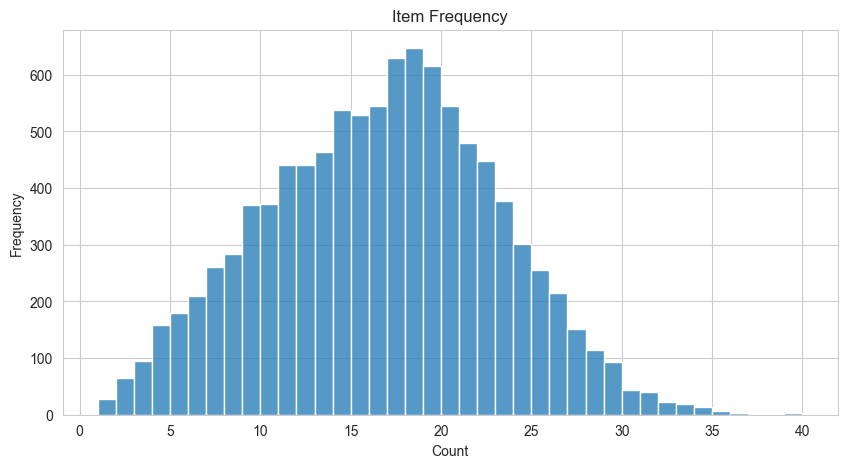

In [14]:
# - `item_id`별 등장 횟수를 세어 분포 확인
# - 인기 아이템과 롱테일 아이템을 직관적으로 볼 수 있음
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(x=df["item_id"].value_counts(), binwidth=1)
plt.title("Item Frequency")
plt.xlabel("Count")  # 특정 아이템이 등장한 횟수
plt.ylabel("Frequency")  # 등장 횟수별 아이템의 개수
plt.show()